--- TASK 1: CLEANING DATASET ---
Data cleaning successful. Total clean records: 500
   Patient_ID   Age  Gender   Disease                Admission_Date  \
0         101  52.0  Female  Diabetes 2023-01-01 00:00:00.000000000   
1         102  15.0  Female   Malaria 2023-01-01 17:30:25.250501002   
2         103  72.0    Male  Diabetes 2023-01-02 11:00:50.501002004   

   Days_Admitted   Bill_Amount Age_Group  
0              5  43015.245265     Adult  
1              4  39246.079592      Teen  
2              3  33179.914473    Senior  

--- TASK 2: ANALYZING PATIENT COUNTS ---

Patient Count by Disease:
Disease
Malaria          95
Flu              86
Diabetes         83
Heart Disease    81
Covid-19         80
Dengue           75
Name: count, dtype: int64

Patient Count by Age Group:
Age_Group
Senior         155
Adult          142
Young Adult     96
Child           66
Teen            41
Name: count, dtype: int64

--- TASK 3: IDENTIFYING PEAK ADMISSION PERIODS ---
Admission_Month
January 

/tmp/ipykernel_2126/1284062321.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], data=df, x='Disease', order=df['Disease'].value_counts().index, palette='viridis')


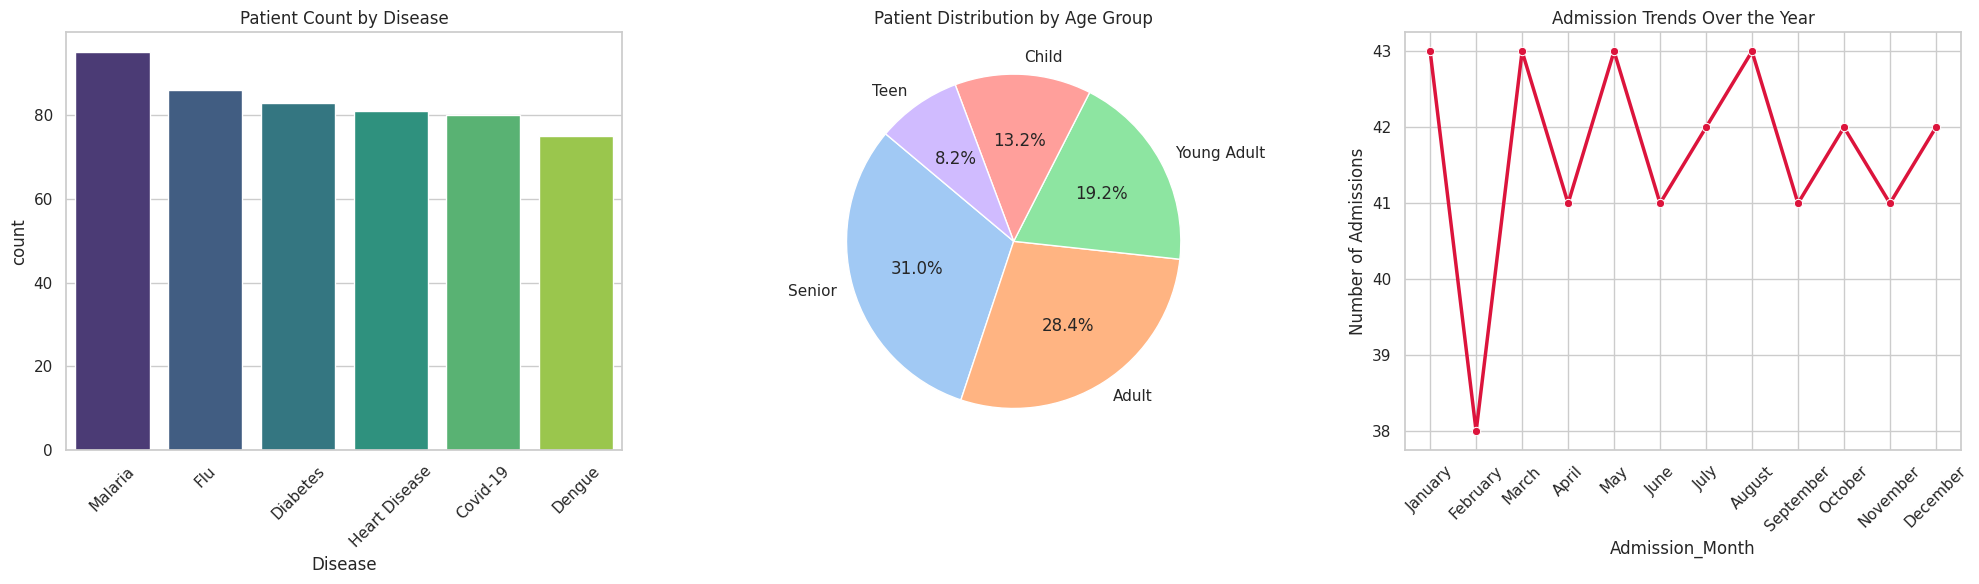

Visualizations displayed successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. DATASET CREATION (MOCK DATA)
# ==========================================
np.random.seed(42)
mock_data = {
    'Patient_ID': range(101, 601),
    'Age': np.random.randint(1, 90, 500),
    'Gender': np.random.choice(['Male', 'Female'], 500),
    'Disease': np.random.choice(['Flu', 'Covid-19', 'Diabetes', 'Dengue', 'Heart Disease', 'Malaria'], 500),
    'Admission_Date': pd.date_range(start='2023-01-01', end='2023-12-31', periods=500),
    'Days_Admitted': np.random.randint(1, 15, 500),
    'Bill_Amount': np.random.uniform(5000, 50000, 500)
}
df = pd.DataFrame(mock_data)

# Introducing duplicates and missing values for cleaning demonstration
df.loc[10:15, 'Age'] = np.nan
df = pd.concat([df, df.iloc[0:5]], ignore_index=True)


# ==========================================
# TASK 1: CLEAN PATIENT DATASET
# ==========================================
print("--- TASK 1: CLEANING DATASET ---")

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing Age values with the median age
df['Age'] = df['Age'].fillna(df['Age'].get('median', df['Age'].median()))

# Convert Admission_Date to datetime object
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# Create Age Group categories
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

print("Data cleaning successful. Total clean records:", len(df))
print(df.head(3))


# ==========================================
# TASK 2: ANALYZE PATIENT COUNT BY DISEASE & AGE GROUP
# ==========================================
print("\n--- TASK 2: ANALYZING PATIENT COUNTS ---")

# Count by Disease
disease_counts = df['Disease'].value_counts()
print("\nPatient Count by Disease:")
print(disease_counts)

# Count by Age Group
age_group_counts = df['Age_Group'].value_counts()
print("\nPatient Count by Age Group:")
print(age_group_counts)


# ==========================================
# TASK 3: IDENTIFY PEAK ADMISSION PERIODS
# ==========================================
print("\n--- TASK 3: IDENTIFYING PEAK ADMISSION PERIODS ---")

# Extract month name from admission date
df['Admission_Month'] = df['Admission_Date'].dt.month_name()

# Count admissions per month
monthly_admissions = df['Admission_Month'].value_counts()

# Sort according to calendar months
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_admissions = monthly_admissions.reindex(months_order)

# Find the peak month
busiest_month = monthly_admissions.idxmax()
highest_count = monthly_admissions.max()

print(monthly_admissions)
print(f"\nResult: Peak admission period is {busiest_month} with {highest_count} admissions.")


# ==========================================
# TASK 4: VISUALIZE PATIENT TRENDS
# ==========================================
print("\n--- TASK 4: GENERATING VISUALIZATIONS ---")

# Set up the plotting grid (1 row, 3 columns)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Patient Count by Disease
sns.countplot(ax=axes[0], data=df, x='Disease', order=df['Disease'].value_counts().index, palette='viridis')
axes[0].set_title('Patient Count by Disease')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Patient Distribution by Age Group
axes[1].pie(age_group_counts, labels=age_group_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title('Patient Distribution by Age Group')

# Plot 3: Admission Trends Over Months
sns.lineplot(ax=axes[2], x=monthly_admissions.index, y=monthly_admissions.values, marker='o', color='crimson', linewidth=2.5)
axes[2].set_title('Admission Trends Over the Year')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('Number of Admissions')

# Adjust layout and render
plt.tight_layout()
plt.show()
print("Visualizations displayed successfully.")